# Projet - Prédiction Sinistre

![](https://imgs.search.brave.com/WXdC7EEYkRxHJG8uX1e-SrHqaRfVUHiMHm_aHKrdVjk/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9tZWRp/YXMubGVjb21wYXJh/dGV1cmFzc3VyYW5j/ZS5jb20vTENBX0Nv/bnRlbnRzL29sZC9h/c3N1cmFuY2UtdGF4/aS1xdWUtZmFpcmUt/Y2FzLXNpbmlzdHJl/LWRlZ3JhZGF0aW9u/LXZlaGljdWxlLndl/YnA)

## Description et objectif du projet :
L'objectif de ce projet est d'analyser l'ensemble des données de réclamations d'assurance afin de développer un modèle prédictif capable de détecter les réclamations potentiellement frauduleuses. 

Dans l'identification des indicateurs clés associés à la fraude, ce modèle vise à aider les compagnies d'assurance à réduire les pertes financières et à améliorer l'efficacité de leurs processus de validation des réclamations.

C'est donc un projet d'*`apprentissage supervisé`* et il traite une problématique de *`classification binaire`* (dite à 2 classes ou 2 variables)
> Le but est d'avoir le *`score F1`* le plus grand possible.

## 1. Chargement et exploration de données

In [1]:
# Importation des packages nécessaires
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud

In [2]:
# Lecture des données
data = pd.read_csv("../data/raw/insurance_claims.csv")

# Affichage des 5 premières lignes du DataFrame
data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [3]:
# Taille du DataFrame
print(f"Ce DataFrame contient {data.shape[0]} lignes et {data.shape[1]} colonnes.")

Ce DataFrame contient 1000 lignes et 40 colonnes.


## 2. Analyse Fondamentale de Données

Il s'agira dans cette partie de comprendre la signification des variables, et surtout le contexte qui entoure ces données.
Cette étape est complémentaire à l'*`Analyse Technique`* qui suit.

In [4]:
# Information sur les données
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   str    
 4   policy_state                 1000 non-null   str    
 5   policy_csl                   1000 non-null   str    
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   str    
 11  insured_education_level      1000 non-null   str    
 12  insured_occupation           1000 non-null   str    
 13  insured_hobbies              1

In [5]:
# Vérification des valeurs manquantes
print(f"Nous avons : {data.isna().sum().sum()} valeurs manquantes.")

print("\nCes valeurs manquantes sont réparties comme suit :")

# Parcours des colonnes pour afficher les valeurs manquantes
for col in data.columns:
    missing_count = data[col].isna().sum()
    if missing_count > 0:
        # Affichage du nombre de valeurs manquantes pour chaque colonne concernée
        print(f"{col} : {missing_count} valeurs manquantes")

Nous avons : 1091 valeurs manquantes.

Ces valeurs manquantes sont réparties comme suit :
authorities_contacted : 91 valeurs manquantes
_c39 : 1000 valeurs manquantes


> *On remarque que la colonne `_c39` est vide (ne contient acune valeur), elle pourra être supprimée et `authorities_contact` contient 91 valeurs manquantes sur 1000, il reste alors 909 valeurs qui sont assez suffisantes pour l'analyse.*

In [6]:
# Suppression de la colonne '_c39' car elle ne contient aucune valeur
data = data.drop(columns = "_c39")

In [7]:
# Vérification de la suppression de _c39
print(data.columns)

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported'],
      dtype='str')


In [8]:
# Vérification des valeurs en double dans le DataFrame
print(f"Nombre de lignes en double dans le DataFrame : {data.duplicated().sum()}")

Nombre de lignes en double dans le DataFrame : 0


In [9]:
# Liste des colonnes contenant des dates étant au format "string"
date_columns = ["incident_date", "policy_bind_date",]

# Parcourir les colonnes de date pour les convertir en datetime
for col in date_columns:
    data[col] = pd.to_datetime(data[col], errors="coerce") # Conversion

In [10]:
# Vérification de l'application de la conversion
print(data[date_columns].dtypes)

incident_date       datetime64[us]
policy_bind_date    datetime64[us]
dtype: object


> *La conversion des colonnes ayant des dates permettra une bonne analyse, notamment l'analyse temporelle envue de découvrir les tendances dans les incidents.*

In [11]:
# Sélection des variables numériques et stats descriptives avec la sortie en transposée
num_cols = data.select_dtypes(include=np.number).describe().T

# Affichage des stats par ordre croissant suivant la moyenne
num_cols.sort_values("mean", ascending = True)

,count,mean,std,min,25%,50%,75%,max
capital-loss,1000.0,-2.679370e+04,2.810410e+04,-111100.00,-51500.0000,-23250.0,0.000,0.00
bodily_injuries,1000.0,9.920000e-01,8.201272e-01,0.00,0.0000,1.0,2.000,2.00
witnesses,1000.0,1.487000e+00,1.111335e+00,0.00,1.0000,1.0,2.000,3.00
number_of_vehicles_involved,1000.0,1.839000e+00,1.018880e+00,1.00,1.0000,1.0,3.000,4.00
incident_hour_of_the_day,1000.0,1.164400e+01,6.951373e+00,0.00,6.0000,12.0,17.000,23.00
age,1000.0,3.894800e+01,9.140287e+00,19.00,32.0000,38.0,44.000,64.00
months_as_customer,1000.0,2.039540e+02,1.151132e+02,0.00,115.7500,199.5,276.250,479.00
policy_deductable,1000.0,1.136000e+03,6.118647e+02,500.00,500.0000,1000.0,2000.000,2000.00
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.33,1089.6075,1257.2,1415.695,2047.59
auto_year,1000.0,2.005103e+03,6.015861e+00,1995.00,2000.0000,2005.0,2010.000,2015.00


In [12]:
# Ratio de détection des valeurs extrêmes
num_cols["max_q75_ratio"] = num_cols["max"] / num_cols["75%"]

# Affichage des 10 premières variables potentielles aux outliers 
num_cols.sort_values("max_q75_ratio", ascending = False).head(15) # Ordre croissant

,count,mean,std,min,25%,50%,75%,max,max_q75_ratio
umbrella_limit,1000.0,1.101000e+06,2.297407e+06,-1000000.00,0.0000,0.0,0.000,10000000.00,inf
property_claim,1000.0,7.399570e+03,4.824726e+03,0.00,4445.0000,6750.0,10885.000,23670.00,2.174552
capital-gains,1000.0,2.512610e+04,2.787219e+04,0.00,0.0000,0.0,51025.000,100500.00,1.969623
injury_claim,1000.0,7.433420e+03,4.880952e+03,0.00,4295.0000,6775.0,11305.000,21450.00,1.897391
months_as_customer,1000.0,2.039540e+02,1.151132e+02,0.00,115.7500,199.5,276.250,479.00,1.733937
total_claim_amount,1000.0,5.276194e+04,2.640153e+04,100.00,41812.5000,58055.0,70592.500,114920.00,1.627935
vehicle_claim,1000.0,3.792895e+04,1.888625e+04,70.00,30292.5000,42100.0,50822.500,79560.00,1.565448
witnesses,1000.0,1.487000e+00,1.111335e+00,0.00,1.0000,1.0,2.000,3.00,1.500000
age,1000.0,3.894800e+01,9.140287e+00,19.00,32.0000,38.0,44.000,64.00,1.454545
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.33,1089.6075,1257.2,1415.695,2047.59,1.446350


>*Ces 10 premières variables méritent une attention très particulière en raison de leur valeurs très significatives, elles peuvent presenter des distributions assymétriques et influence énormement l'entrainement du modèle. Mais toutes ces assertions vont être vérifiées afin d'aller en profondeur et elles doivent faire l'`objet d'une analyse spécifique.`*

In [13]:
# Valeurs uniques de chaque colonne
data.nunique()

months_as_customer              391
age                              46
policy_number                  1000
policy_bind_date                951
policy_state                      3
policy_csl                        3
policy_deductable                 3
policy_annual_premium           991
umbrella_limit                   11
insured_zip                     995
insured_sex                       2
insured_education_level           7
insured_occupation               14
insured_hobbies                  20
insured_relationship              6
capital-gains                   338
capital-loss                    354
incident_date                    60
incident_type                     4
collision_type                    4
incident_severity                 4
authorities_contacted             4
incident_state                    7
incident_city                     7
incident_location              1000
incident_hour_of_the_day         24
number_of_vehicles_involved       4
property_damage             

>*De première vue, tous les lieux où les incidents se sont produits sont tous disctinctes.*

### 2-1. Que représente une ligne de chaque colonne ?
>Chaque ligne représente un sinistre d'assurance automobile avec les détails du client , de la police, de >l'incident et des montants réclamés. 

### 2-1-1. Dictionnaire de données

| Variable | Type | Description |
|----------|------|-------------|
| months_as_customer | int | Nombre de mois depuis lequel le client est assuré |
| age | int | Âge du client au moment du sinistre |
| policy_number | int | Numéro unique de la police d'assurance |
| policy_bind_date | datetime | Date de signature de la police |
| policy_state | object | État où la police a été émise |
| policy_csl | object | Couverture de responsabilité civile (Combined Single Limit) |
| policy_deductable | int | Montant de la franchise d'assurance |
| policy_annual_premium | float | Prime d'assurance annuelle en dollars |
| umbrella_limit | int | Limite de couverture supplémentaire (parapluie) en dollars |
| insured_zip | int | Code postal du client assuré |
| insured_sex | object | Sexe du client assuré (MALE/FEMALE) |
| insured_education_level | object | Niveau d'éducation du client (HS, MD, PhD) |
| insured_occupation | object | Profession du client assuré |
| insured_hobbies | object | Loisirs/hobbies du client |
| insured_relationship | object | Lien de parenté/relation du client |
| capital-gains | int | Gains en capital du client |
| capital-loss | int | Pertes en capital du client |
| incident_date | datetime | Date de l'incident/sinistre |
| incident_type | object | Type de sinistre (Single Vehicle Collision, Vehicle Theft, Multi-vehicle Collision) |
| collision_type | object | Type de collision (Front, Rear, Side Collision) |
| incident_severity | object | Gravité du sinistre (Minor, Major Damage, Total Loss) |
| authorities_contacted | object | Autorités contactées (Police, Tristate) |
| incident_state | object | État où s'est produit le sinistre |
| incident_city | object | Ville où s'est produit le sinistre |
| incident_location | object | Localisation spécifique du sinistre |
| incident_hour_of_the_day | int | Heure du jour du sinistre (0-23) |
| number_of_vehicles_involved | int | Nombre de véhicules impliqués dans le sinistre |
| property_damage | object | Présence de dommages matériels (YES/NO/?) |
| bodily_injuries | int | Nombre de blessures corporelles |
| witnesses | int | Nombre de témoins du sinistre |
| police_report_available | object | Disponibilité d'un rapport de police (YES/NO/?) |
| total_claim_amount | int | Montant total de la réclamation en dollars |
| injury_claim | int | Montant de la réclamation pour blessures corporelles |
| property_claim | int | Montant de la réclamation pour dommages matériels |
| vehicle_claim | int | Montant de la réclamation pour dommages véhicule |
| auto_make | object | Marque du véhicule impliqué |
| auto_model | object | Modèle du véhicule impliqué |
| auto_year | int | Année de fabrication du véhicule |
| fraud_reported | object | **[CIBLE]** Fraude déclarée (Y=Oui/N=Non) |

### 2-2. Qui a récolté ces données ?

>Ces données ont été récoltées par **Abdelrahim Aqqad** un auditeur interne en chef et un expert en comptabilité judiciaire basé à Doha, au Qatar, avec plus de 15 ans d'expérience dans l'audit opérationnel, financier et informatique, la gouvernance, la gestion des risques et les contrôles internes.
>
>Il est l'un des pionniers de l'utilisation de la *Data Science* et de l'*Analyse de Fraude* dans l'audit interne. 

### 2-3. Quand est-ce qu'elles ont été récoltées ?

> Ces données ont été récoltées en 2015

### 2-4. Où est-ce qu'elles ont été récoltées ?

> Ces données ont été récoltées en 2015 aux Etats Unis d'Amerique (USA)

### 2-5. Comment ont elles été récoltées ?

> Ces données ont été récoltées en 2015 aux Etats Unis d'Amerique (USA) via des compagnies de fournisseurs d'assurance.

### 2-6. Pourquoi est-ce qu'elles ont été récoltées ?

> Ces données ont été récoltées en 2015 aux Etats Unis d'Amerique (USA) via des compagnies de fournisseurs d'assurance dans le but de mener des travaux d'études dans le secteur de la finance pour des cas d'audit internes.

## 3. Analyse Technique de Données

Dans cette partie, il s'agira de voir les relations qui existent entre les différentes variables (`correlations`), identifier les variables les plus pertienentes, celles qui serviront au dévoloppement du modèle de `Machine Learning`

In [14]:
# Sélection des variables numériques
num_cols = data.select_dtypes(include=np.number).columns.tolist()
num_cols

['months_as_customer',
 'age',
 'policy_number',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'capital-gains',
 'capital-loss',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'bodily_injuries',
 'witnesses',
 'total_claim_amount',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 'auto_year']

In [15]:
# Sélection des colonnes catégorielles
cat_cols = data.select_dtypes(exclude=np.number).columns.tolist()
cat_cols

['policy_bind_date',
 'policy_state',
 'policy_csl',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'incident_date',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_location',
 'property_damage',
 'police_report_available',
 'auto_make',
 'auto_model',
 'fraud_reported']

Avant de passer à l'`analyse technique`, il est important de définir quelles sont les variables discrètes et continues, en effet, cela nous permettra de bien aborder nos analyses.

### Variables discrètes (Catégorielles) : 
- policy_bind_date
- policy_state
- policy_csl
- insured_sex
- insured_education_level
- insured_occupation
- insured_hobbies
- insured_relationship
- incident_date
- incident_type
- collision_type
- incident_severity
- authorities_contacted
- incident_state
- incident_city
- incident_location
- property_damage
- police_report_available
- auto_make
- auto_model
- fraud_reported

### Variables continues :
- months_as_customer
- age
- policy_number
- policy_deductable
- policy_annual_premium
- umbrella_limit
- insured_zip
- capital-gains
- capital-loss
- incident_hour_of_the_day
- number_of_vehicles_involved
- bodily_injuries
- witnesses
- total_claim_amount
- injury_claim
- property_claim
- vehicle_claim
- auto_year

### 3-1. Analyse Univariée des variables

Il s'agit d'analyser les variables séparement les unes des autres

In [16]:
# Réaffichage des 5 premières lignes du DataFrame
data[cat_cols].head()

,policy_bind_date,policy_state,policy_csl,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,incident_date,incident_type,...,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,property_damage,police_report_available,auto_make,auto_model,fraud_reported
0,2014-10-17,OH,250/500,MALE,MD,craft-repair,sleeping,husband,2015-01-25,Single Vehicle Collision,...,Major Damage,Police,SC,Columbus,9935 4th Drive,YES,YES,Saab,92x,Y
1,2006-06-27,IN,250/500,MALE,MD,machine-op-inspct,reading,other-relative,2015-01-21,Vehicle Theft,...,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,?,?,Mercedes,E400,Y
2,2000-09-06,OH,100/300,FEMALE,PhD,sales,board-games,own-child,2015-02-22,Multi-vehicle Collision,...,Minor Damage,Police,NY,Columbus,7121 Francis Lane,NO,NO,Dodge,RAM,N
3,1990-05-25,IL,250/500,FEMALE,PhD,armed-forces,board-games,unmarried,2015-01-10,Single Vehicle Collision,...,Major Damage,Police,OH,Arlington,6956 Maple Drive,?,NO,Chevrolet,Tahoe,Y
4,2014-06-06,IL,500/1000,MALE,Associate,sales,board-games,unmarried,2015-02-17,Vehicle Theft,...,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,NO,NO,Accura,RSX,N


### 3-1-1. Analyse des variables catégorielles (qualitatives)

In [17]:
# Représentation graphique de la répartition de la target, 
# Utilisation plotly pour une visualisation interactive.
fig = px.pie(names = data["fraud_reported"].value_counts().index, 
             values = data["fraud_reported"].value_counts().values, 
             title = "Répartition de la target")
fig.show()

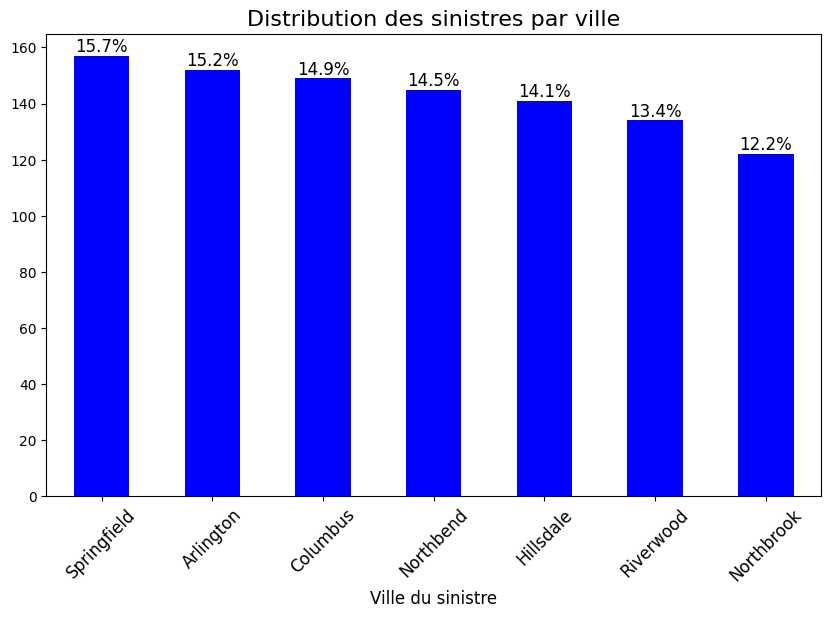

In [18]:
# Nombre de villes dans lesquelles des sinistres ont été déclarés
num_unique_cities = data["incident_city"].value_counts().sum()

# Espace de travail
plt.figure(figsize=(10, 6))

# Graphique des sinistres par ville
ax = data["incident_city"].value_counts().plot(kind="bar", color="blue")

# Ajout des pourcentages sur chaque barre
for p in ax.patches:
    percentage = f"{100 * p.get_height() / num_unique_cities:.1f}%"
    ax.annotate(
        percentage, (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=12, color="black"
    )

# Titre du graphique
plt.title("Distribution des sinistres par ville", fontsize=16)

# Rotation des étiquettes de l'axe x
plt.xticks(rotation=45, fontsize=12)
# Labélisage de l'axe x
plt.xlabel("Ville du sinistre", fontsize=12);

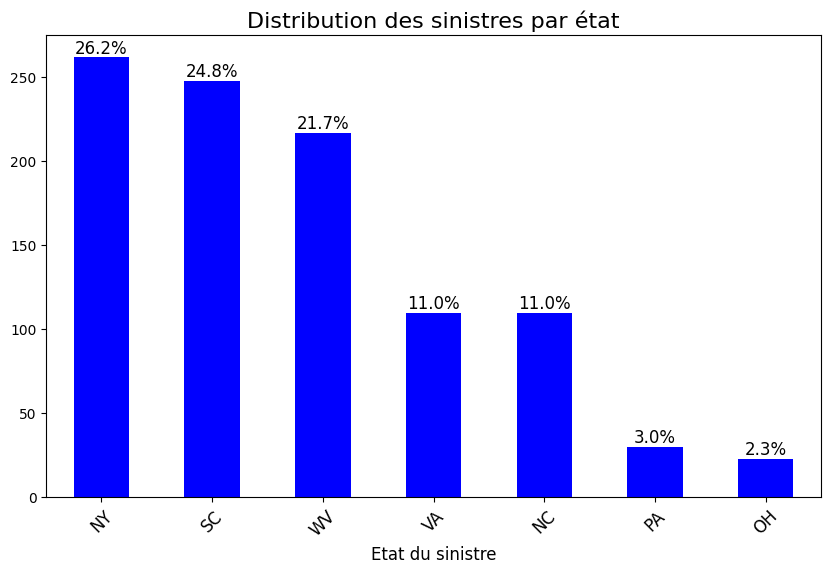

In [19]:
# Nombre d'états dans lesquelles des sinistres ont été déclarés
num_unique_cities = data["incident_state"].value_counts().sum()

# Espace de travail
plt.figure(figsize=(10, 6))

# Graphique des sinistres par état
ax = data["incident_state"].value_counts().plot(kind="bar", color="blue")

# Ajout des pourcentages sur chaque barre
for p in ax.patches:
    percentage = f"{100 * p.get_height() / num_unique_cities:.1f}%"
    ax.annotate(
        percentage, (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=12, color="black"
    )

# Titre du graphique
plt.title("Distribution des sinistres par état", fontsize=16)

# Rotation des étiquettes de l'axe x
plt.xticks(rotation=45, fontsize=12)
# Labélisage de l'axe x
plt.xlabel("Etat du sinistre", fontsize=12);

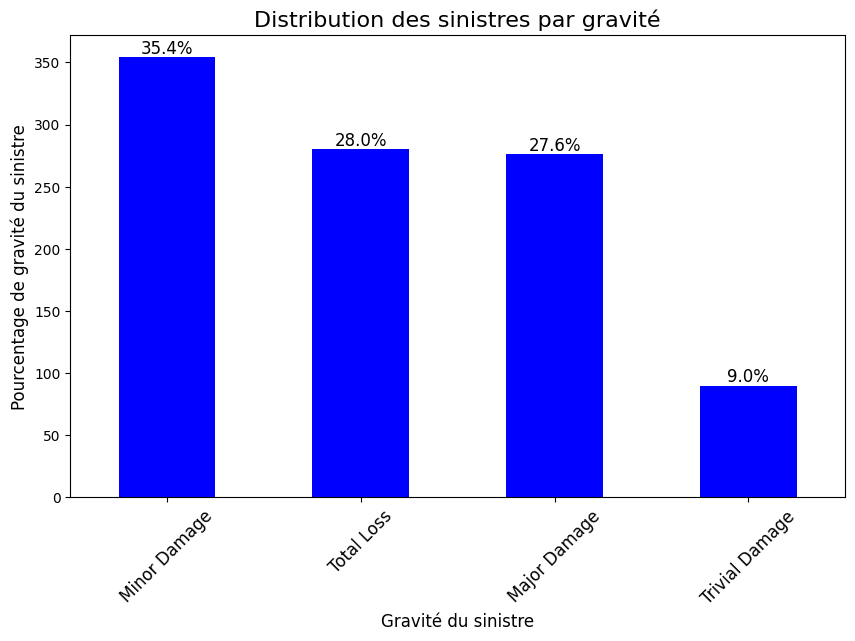

In [20]:
# Nombre de gravité de sinistre
sin_gravity = data["incident_severity"].value_counts().sum()

# Espace de travail
plt.figure(figsize = (10, 6))

# Graphique du nombre de sinistres par gravité
ax = data["incident_severity"].value_counts().plot(kind="bar", color = "blue")

# Ajout des pourcentages sur chaque barre
for p in ax.patches:
    percentage = f"{100 * p.get_height() / sin_gravity:.1f}%"
    ax.annotate(
        percentage, (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=12, color="black"
    )

# Titre du graphique
plt.title("Distribution des sinistres par gravité", fontsize=16)

# Rotation des étiquettes de l'axe x
plt.xticks(rotation=45, fontsize=12)
# Labélisage des axes
plt.xlabel("Gravité du sinistre", fontsize=12)
plt.ylabel("Pourcentage de gravité du sinistre", fontsize=12);

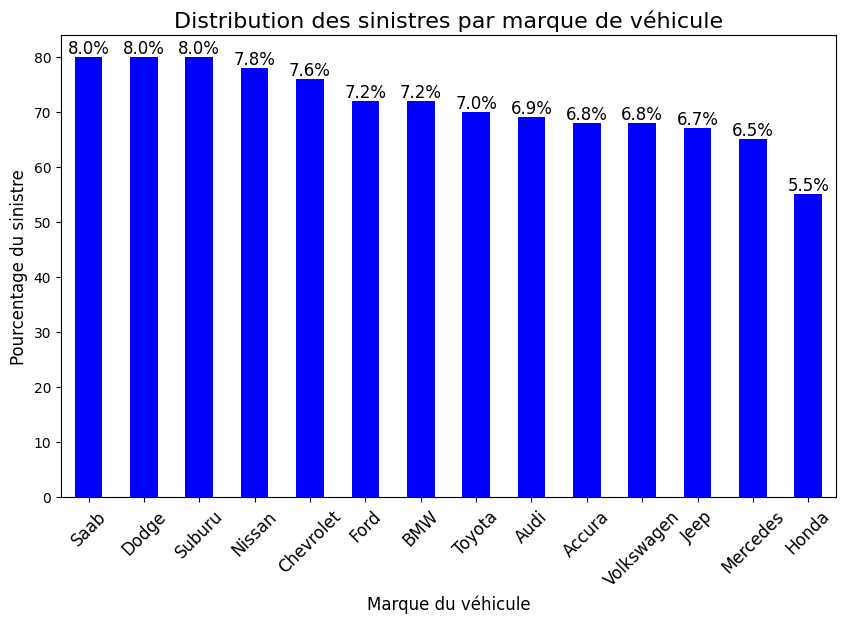

In [21]:
# Nombre de marque de véhicule par sinistre
sin_vehicule = data["auto_make"].value_counts().sum()

# Espace de travail
plt.figure(figsize = (10, 6))

# Graphique du nombre de sinistres par véhicule
ax = data["auto_make"].value_counts().plot(kind="bar", color = "blue")

# Ajout des pourcentages sur chaque barre
for p in ax.patches:
    percentage = f"{100 * p.get_height() / sin_vehicule:.1f}%"
    ax.annotate(
        percentage, (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=12, color="black"
    )

# Titre du graphique
plt.title("Distribution des sinistres par marque de véhicule", fontsize=16)

# Rotation des étiquettes de l'axe x
plt.xticks(rotation=45, fontsize=12)
# Labélisage des axes
plt.xlabel("Marque du véhicule", fontsize=12)
plt.ylabel("Pourcentage du sinistre", fontsize=12);

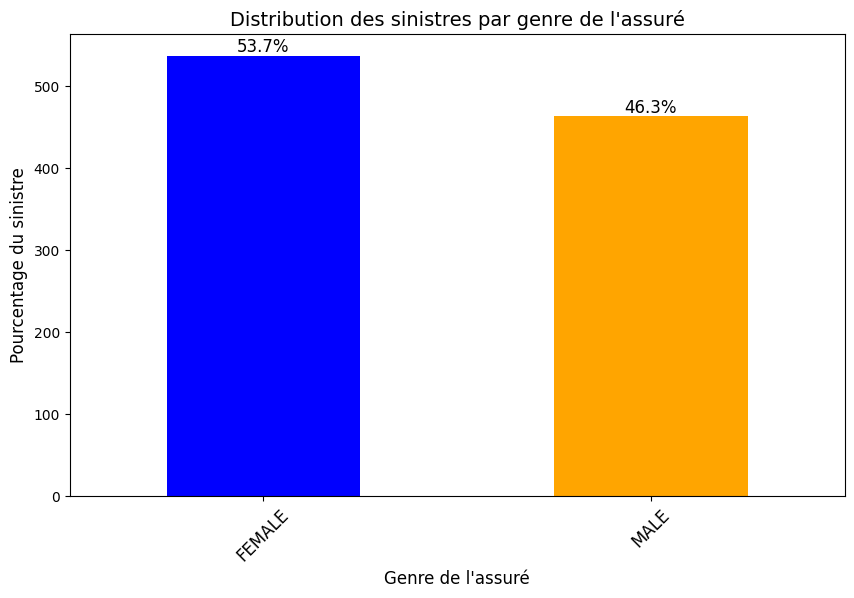

In [22]:
# Nombre de genre de l'assuré du sinistre
sin_genre = data["insured_sex"].value_counts().sum()

# Espace de travail
plt.figure(figsize = (10, 6))

# Graphique du nombre de genre d'assuré par sinistre
ax = data["insured_sex"].value_counts().plot(kind="bar", color=["blue", "orange"], ax=plt.gca())

# Ajoute des pourcentages sur chaque barre
for p in ax.patches:
    percentage = f"{100 * p.get_height() / sin_genre:.1f}%"
    ax.annotate(
        percentage, (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=12, color="black"
    )

# Titre du graphique
plt.title("Distribution des sinistres par genre de l'assuré", fontsize=14)
# Rotation des étiquettes de l'axe x
plt.xticks(rotation=45, fontsize=12)
# Labélisage des axes
plt.xlabel("Genre de l'assuré", fontsize=12)
plt.ylabel("Pourcentage du sinistre", fontsize=12);

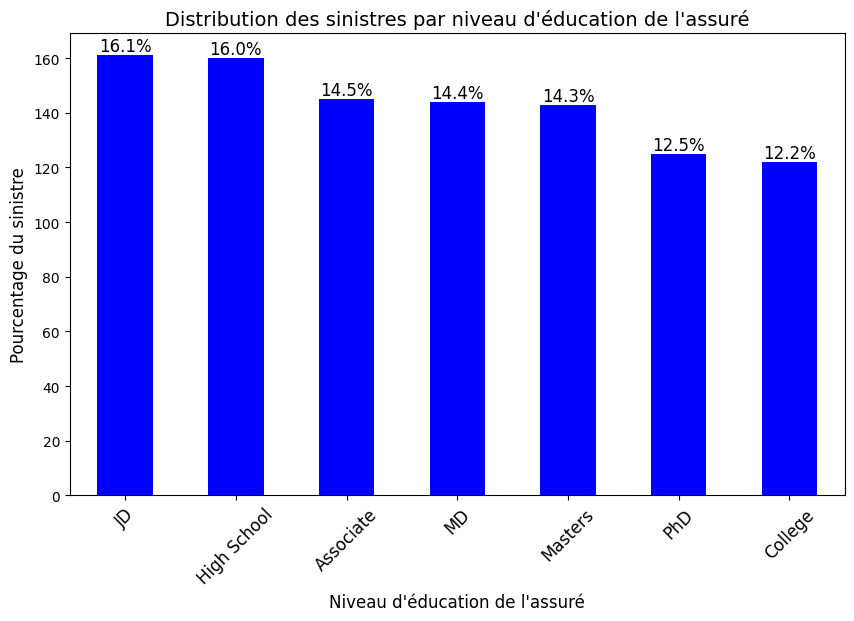

In [23]:
# Nombre de niveau d'éducation de l'assuré du sinistre
sin_educ = data["insured_education_level"].value_counts().sum()

# Espace de travail
plt.figure(figsize = (10, 6))

# Distribution des sinistres par niveau d'éducation de l'assuré
ax = data["insured_education_level"].value_counts().plot(kind="bar", color = "blue")

# Ajout des pourcentages sur chaque barre
for p in ax.patches:
    percentage = f"{100 * p.get_height() / sin_educ:.1f}%"
    ax.annotate(
        percentage, (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=12, color="black"
     )
    
# Titre du graphique
plt.title("Distribution des sinistres par niveau d'éducation de l'assuré", fontsize=14)
# Rotation des étiquettes de l'axe x
plt.xticks(rotation=45, fontsize=12)
# Labélisage des axes
plt.xlabel("Niveau d'éducation de l'assuré", fontsize=12)
plt.ylabel("Pourcentage du sinistre", fontsize=12);

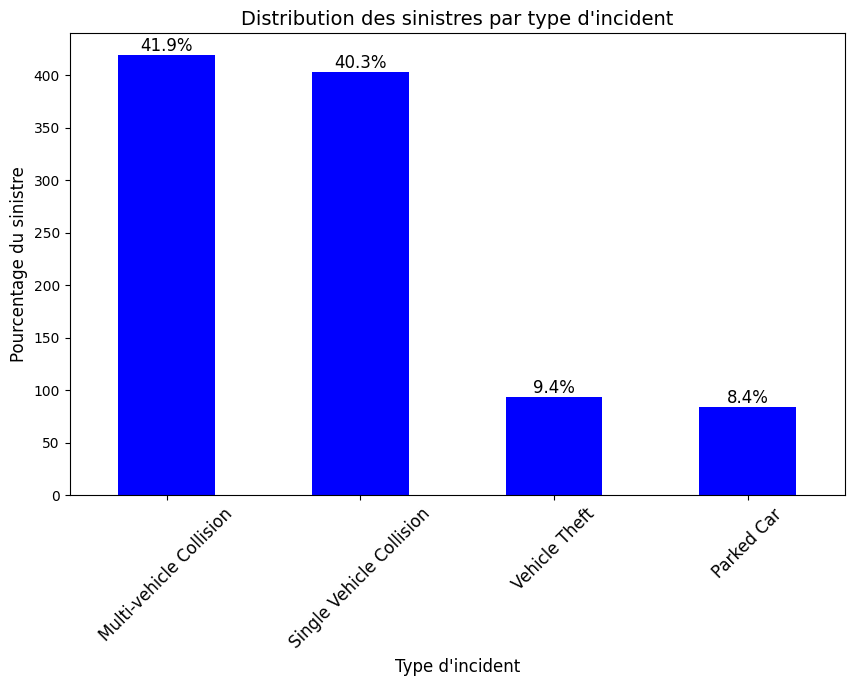

In [24]:
# Nombre de type d'incident
sin_type = data["incident_type"].value_counts().sum()

# Espace de travail
plt.figure(figsize=(10, 6))

# Distribution du nombre d'incidents par type
ax = data["incident_type"].value_counts().plot(kind="bar", color = "blue")

for p in ax.patches:
    percentage = f"{100 * p.get_height() / sin_type:.1f}%"
    ax.annotate(
        percentage, (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=12, color="black"
     )
    
# Titre du graphique
plt.title("Distribution des sinistres par type d'incident", fontsize=14)
# Rotation des étiquettes de l'axe x
plt.xticks(rotation=45, fontsize=12)
# Labélisage des axes
plt.xlabel("Type d'incident", fontsize=12)
plt.ylabel("Pourcentage du sinistre", fontsize=12);

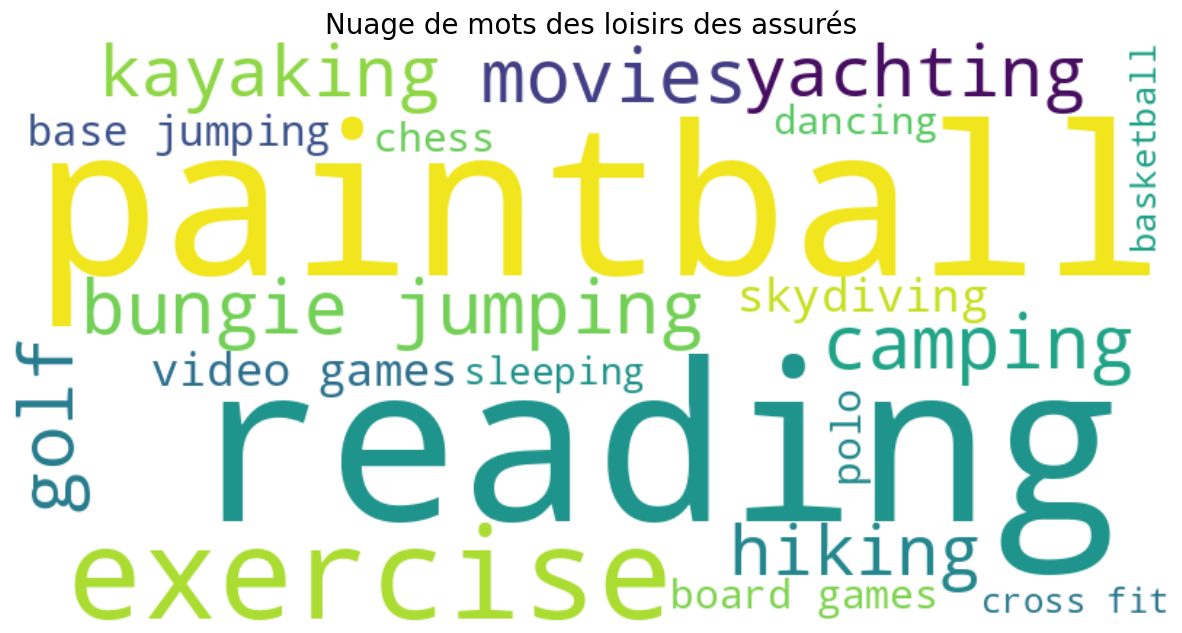

In [25]:
# Valeurs des loisirs de chaque assuré
sin_loisirs = data["insured_hobbies"].values

# Conversion des loisirs en une seule chaîne de caractères
loisirs_text = " ".join(sin_loisirs)

# Objet WordCloud pour générer le nuage de mots
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(loisirs_text)

# Espace de travail pour le nuage de mots
plt.figure(figsize=(15, 8))

# Nuage de mots
plt.imshow(wordcloud, interpolation="bilinear")
# Suppression des axes
plt.axis("off")
# Titre du graphique
plt.title("Nuage de mots des loisirs des assurés", fontsize=20);

### 3-1-2. Analyse des variables continues (numériques)

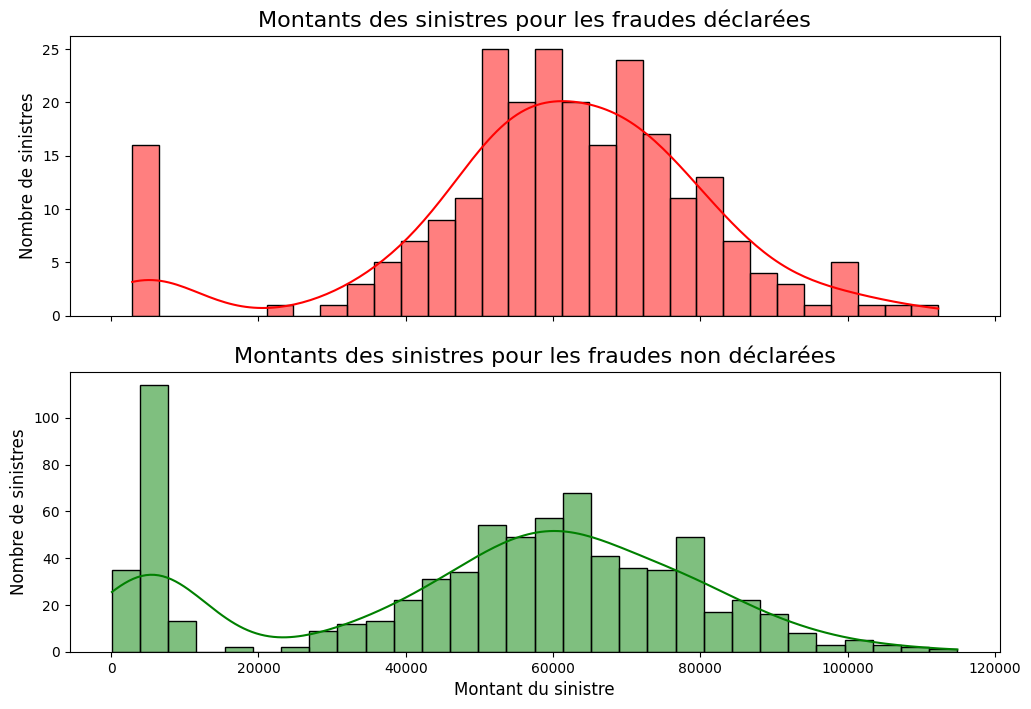

In [26]:
# Espace de travail
fig, ax = plt.subplots(2, 1, figsize = (12, 8), sharex = True)

# Histogramme des montants des sinistres pour les fraudes déclarées
sns.histplot(data[data["fraud_reported"] == "Y"]["total_claim_amount"], 
             bins = 30, color = "red", kde = True, ax = ax[0])
ax[0].set_title("Montants des sinistres pour les fraudes déclarées", fontsize = 16)
ax[0].set_ylabel("Nombre de sinistres", fontsize = 12)

# Histogramme des montants des sinistres pour les fraudes non déclarées
sns.histplot(data[data["fraud_reported"] == "N"]["total_claim_amount"], 
             bins = 30, color = "green", kde = True, ax = ax[1])
ax[1].set_title("Montants des sinistres pour les fraudes non déclarées", fontsize = 16)
ax[1].set_xlabel("Montant du sinistre", fontsize = 12)
ax[1].set_ylabel("Nombre de sinistres", fontsize = 12);

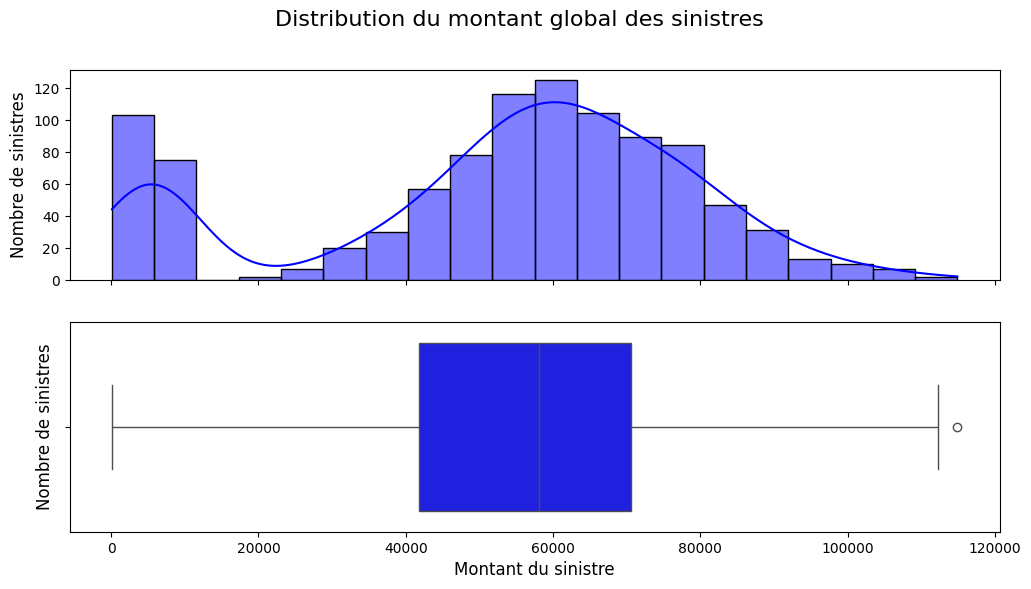

In [27]:
# Dessiner l'espace de travail partagé
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Titre du graphique
fig.suptitle("Distribution du montant global des sinistres", fontsize=16)

# Distribution du montant des sinistres en histogramme
sns.histplot(data=data, x="total_claim_amount", ax=ax[0], kde=True, color="blue")
# Distribution du montant des sinistres en boîte à moustaches
sns.boxplot(data=data, x="total_claim_amount", ax=ax[1], color="blue")

# La distributution en moustaches permet de voir la présence de valeurs extrêmes (outliers)
ax[1].set_xlabel("Montant du sinistre", fontsize=12)
ax[0].set_ylabel("Nombre de sinistres", fontsize=12)
ax[1].set_ylabel("Nombre de sinistres", fontsize=12);

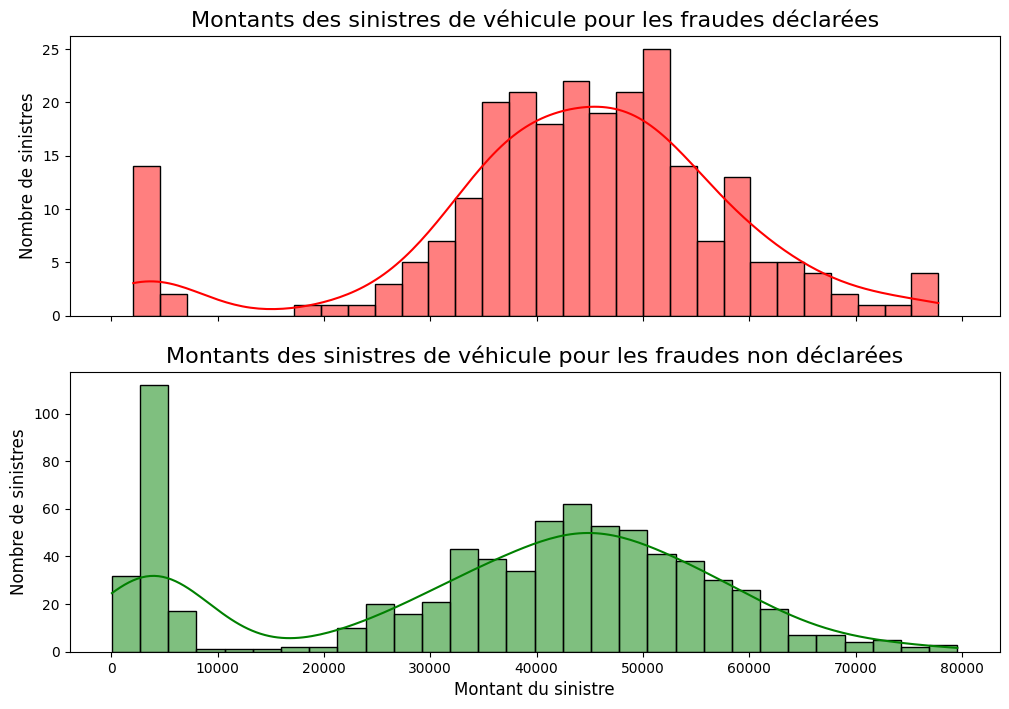

In [28]:
# Espace de travail
fig, ax = plt.subplots(2, 1, figsize = (12, 8), sharex = True)

# Histogramme des montants des sinistres de véhicule pour les fraudes déclarées
sns.histplot(data[data["fraud_reported"] == "Y"]["vehicle_claim"], 
             bins = 30, color = "red", kde = True, ax = ax[0])
ax[0].set_title("Montants des sinistres de véhicule pour les fraudes déclarées", fontsize = 16)
ax[0].set_ylabel("Nombre de sinistres", fontsize = 12)

# Histogramme des montants des sinistres de véhicule pour les fraudes non déclarées
sns.histplot(data[data["fraud_reported"] == "N"]["vehicle_claim"], 
             bins = 30, color = "green", kde = True, ax = ax[1])
ax[1].set_title("Montants des sinistres de véhicule pour les fraudes non déclarées", fontsize = 16)
ax[1].set_xlabel("Montant du sinistre", fontsize = 12)
ax[1].set_ylabel("Nombre de sinistres", fontsize = 12);

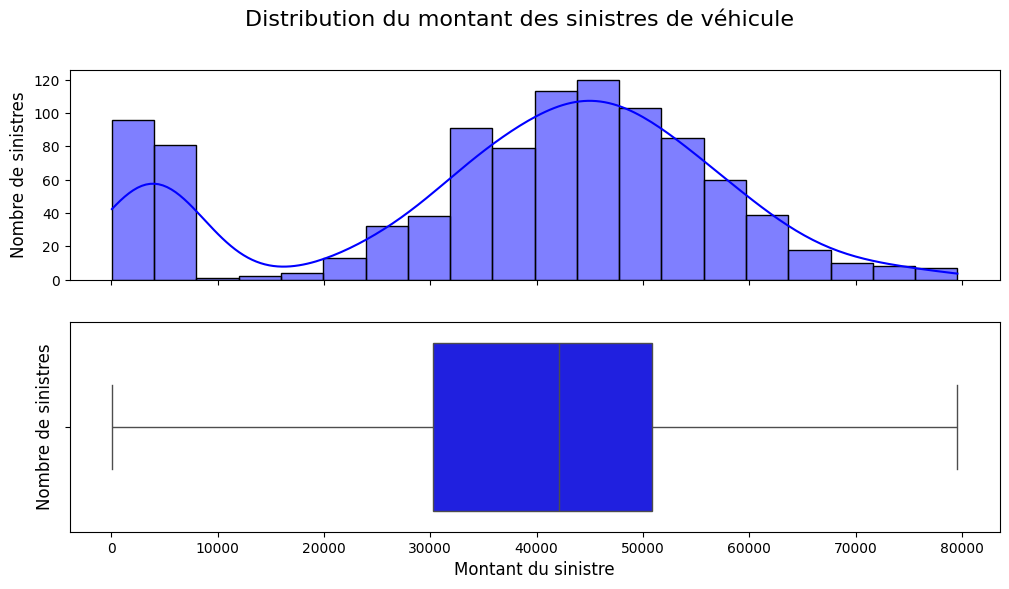

In [29]:
# Dessiner l'espace de travail partagé
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Titre du graphique
fig.suptitle("Distribution du montant des sinistres de véhicule", fontsize=16)

# Distribution du montant des sinistres de véhicule histogramme
sns.histplot(data=data, x="vehicle_claim", ax=ax[0], kde=True, color="blue")
# Distribution du montant des sinistres de véhicule en boîte à moustaches
sns.boxplot(data=data, x="vehicle_claim", ax=ax[1], color="blue")

# La distributution en moustaches permet de voir la présence de valeurs extrêmes (outliers)
ax[1].set_xlabel("Montant du sinistre", fontsize=12)
ax[0].set_ylabel("Nombre de sinistres", fontsize=12)
ax[1].set_ylabel("Nombre de sinistres", fontsize=12);

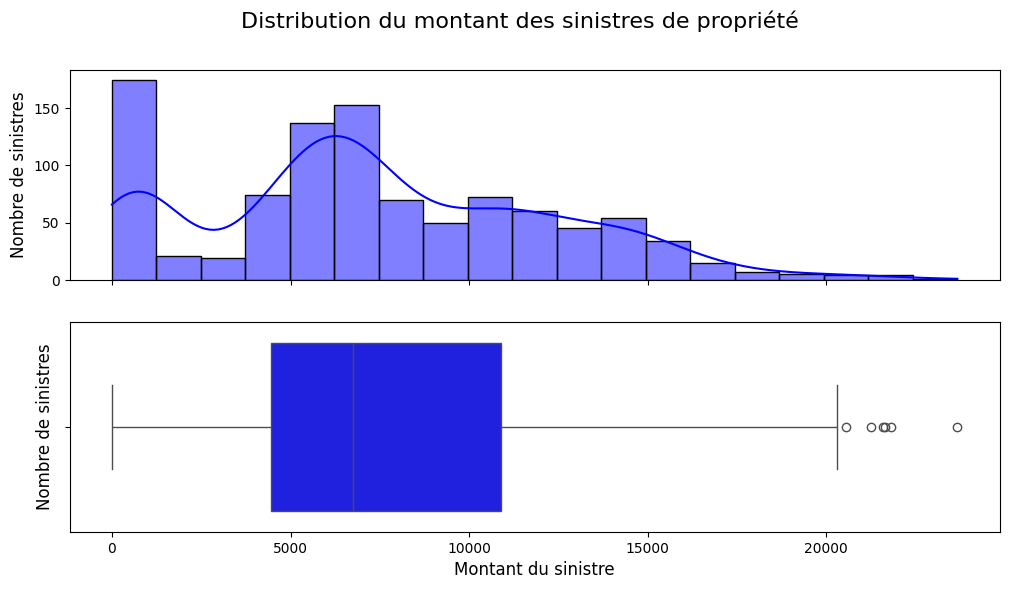

In [30]:
# Dessiner l'espace de travail partagé
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Titre du graphique
fig.suptitle("Distribution du montant des sinistres de propriété", fontsize=16)

# Distribution du montant des sinistres de propriété histogramme
sns.histplot(data=data, x="property_claim", ax=ax[0], kde=True, color="blue")
# Distribution du montant des sinistres de propriété en boîte à moustaches
sns.boxplot(data=data, x="property_claim", ax=ax[1], color="blue")

# La distributution en moustaches permet de voir la présence de valeurs extrêmes (outliers)
ax[1].set_xlabel("Montant du sinistre", fontsize=12)
ax[0].set_ylabel("Nombre de sinistres", fontsize=12)
ax[1].set_ylabel("Nombre de sinistres", fontsize=12);

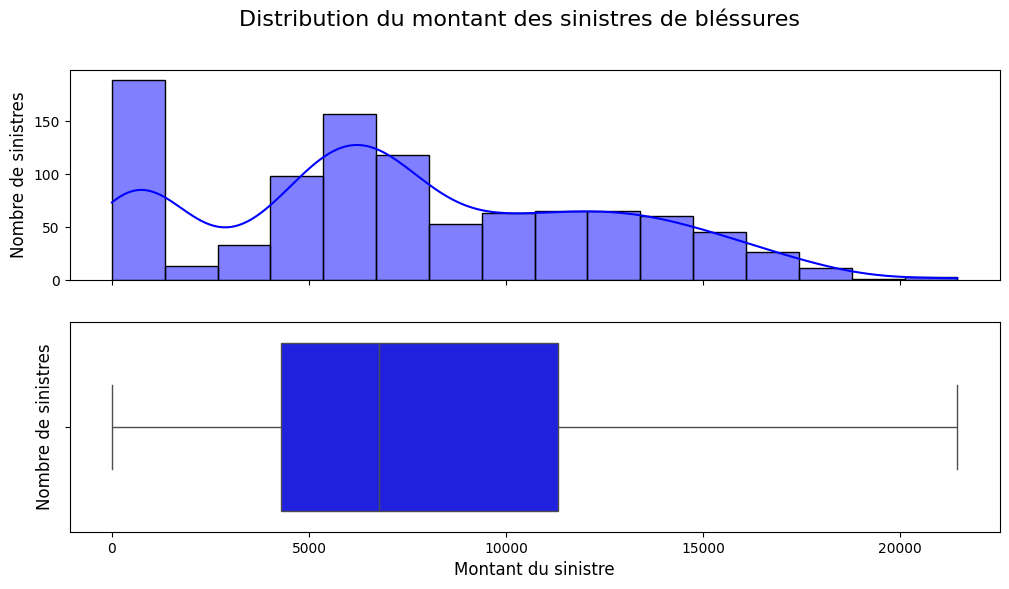

In [31]:
# Dessiner l'espace de travail partagé
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Titre du graphique
fig.suptitle("Distribution du montant des sinistres de bléssures", fontsize=16)

# Distribution du montant des sinistres de bléssures histogramme
sns.histplot(data=data, x="injury_claim", ax=ax[0], kde=True, color="blue")
# Distribution du montant des sinistres de bléssures en boîte à moustaches
sns.boxplot(data=data, x="injury_claim", ax=ax[1], color="blue")

# La distributution en moustaches permet de voir la présence de valeurs extrêmes (outliers)
ax[1].set_xlabel("Montant du sinistre", fontsize=12)
ax[0].set_ylabel("Nombre de sinistres", fontsize=12)
ax[1].set_ylabel("Nombre de sinistres", fontsize=12);

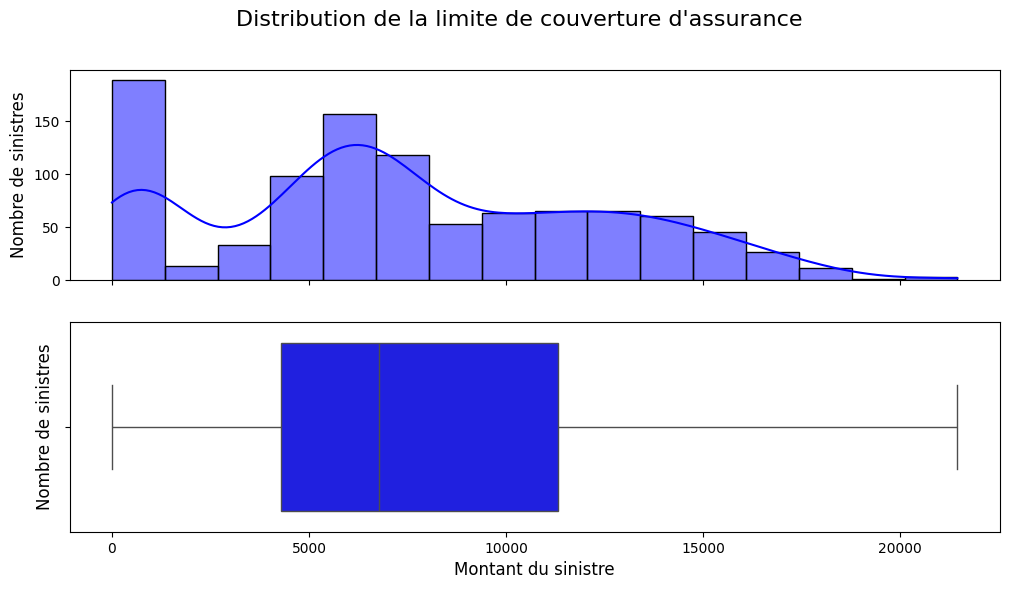

In [32]:
# Dessiner l'espace de travail partagé
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Titre du graphique
fig.suptitle("Distribution de la limite de couverture d'assurance", fontsize=16)

# Distribution du montant de la limite de couverture histogramme
sns.histplot(data=data, x="injury_claim", ax=ax[0], kde=True, color="blue")
# Distribution du montant des sinistres de bléssures en boîte à moustaches
sns.boxplot(data=data, x="injury_claim", ax=ax[1], color="blue")

# La distributution en moustaches permet de voir la présence de valeurs extrêmes (outliers)
ax[1].set_xlabel("Montant du sinistre", fontsize=12)
ax[0].set_ylabel("Nombre de sinistres", fontsize=12)
ax[1].set_ylabel("Nombre de sinistres", fontsize=12);

In [33]:
# Unicité des années de fabrication des véhicules dans le dataset
data["auto_year"].unique()

array([2004, 2007, 2014, 2009, 2003, 2012, 2015, 1996, 2002, 2006, 2000,
       2010, 1999, 2011, 2005, 2008, 1995, 2001, 1998, 1997, 2013])

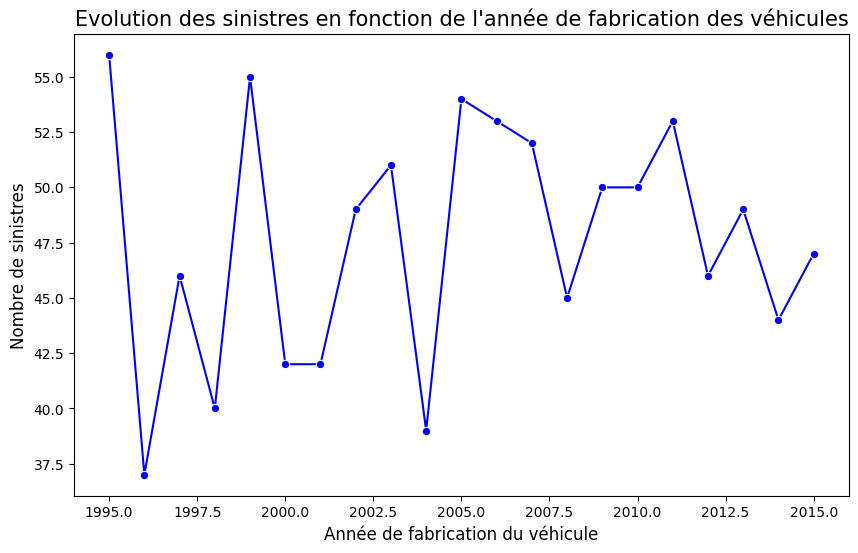

In [34]:
# Espace de travail
plt.figure(figsize=(10, 6))

# Evolution du nombre de sinistres en fonction de l'année de fabrication des véhicules

sns.lineplot(data=data.groupby("auto_year").size().reset_index(name="count"), 
             x="auto_year", y="count", marker="o", color="blue")

# Titre du graphique
plt.title("Evolution des sinistres en fonction de l'année de fabrication des véhicules", fontsize=15)

# Labélisage des axes
plt.xlabel("Année de fabrication du véhicule", fontsize=12)
plt.ylabel("Nombre de sinistres", fontsize=12);

## 3-2. Analyse Multivariée des variables

Dans cette partie, il s'agira de voir les relations entre les différentes variables et surtout comment se comportent les *`features`* envers la *`target`*

In [35]:
# Réaffichage des 5 premières lignes du DataFrame
data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


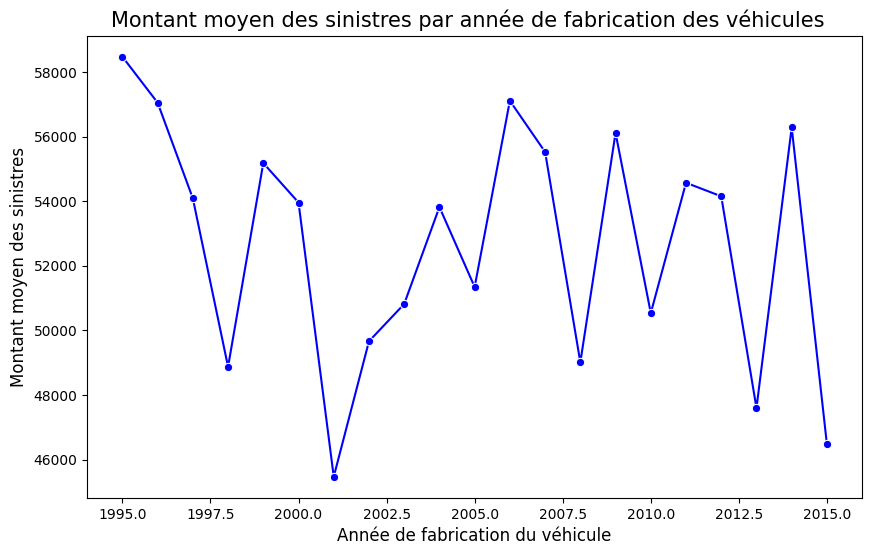

In [36]:
# Espace de travail
plt.figure(figsize=(10, 6))

# Courbes relatives au montant moyen des sinistres en fonction des dates de fabrication des véhicules
sns.lineplot(data=data.groupby("auto_year")["total_claim_amount"].mean().reset_index(), 
             x="auto_year", y="total_claim_amount", marker="o", color="blue")

# Titre du graphique
plt.title("Montant moyen des sinistres par année de fabrication des véhicules  ", fontsize=15)

# Labélisage des axes
plt.xlabel("Année de fabrication du véhicule", fontsize=12)
plt.ylabel("Montant moyen des sinistres", fontsize=12);

In [37]:
# Unicité des variables
data.nunique()

months_as_customer              391
age                              46
policy_number                  1000
policy_bind_date                951
policy_state                      3
policy_csl                        3
policy_deductable                 3
policy_annual_premium           991
umbrella_limit                   11
insured_zip                     995
insured_sex                       2
insured_education_level           7
insured_occupation               14
insured_hobbies                  20
insured_relationship              6
capital-gains                   338
capital-loss                    354
incident_date                    60
incident_type                     4
collision_type                    4
incident_severity                 4
authorities_contacted             4
incident_state                    7
incident_city                     7
incident_location              1000
incident_hour_of_the_day         24
number_of_vehicles_involved       4
property_damage             

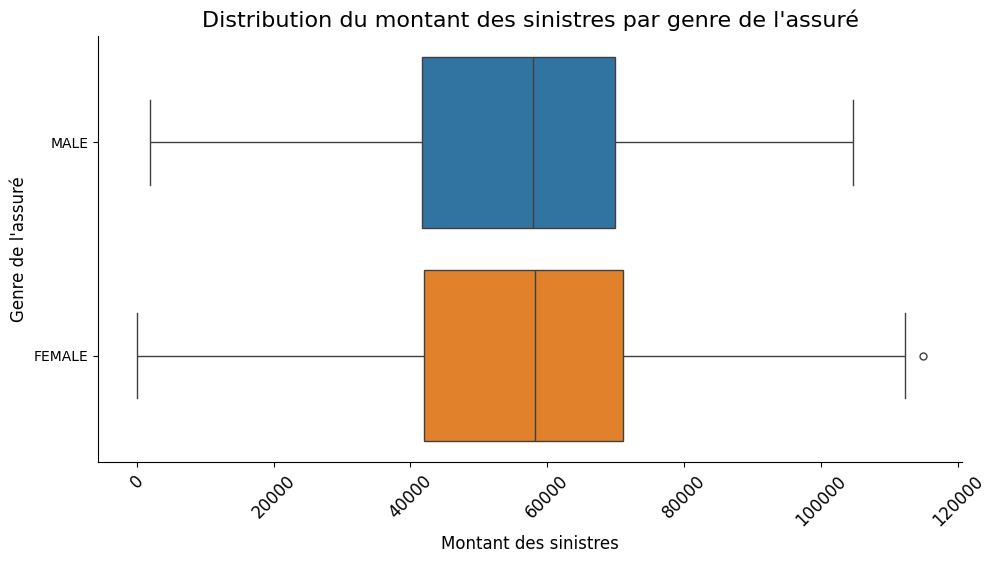

In [38]:
# Distribution du salaire par genre de l'assuré
sns.catplot(
    data=data,x="total_claim_amount", 
    y="insured_sex", hue="insured_sex", 
    kind="box", height=5, aspect=2,
)
# Ajout du titre du graphique
plt.title("Distribution du montant des sinistres par genre de l'assuré", fontsize=16)

# Rotation des étiquettes de l'axe x
plt.xticks(rotation=45, fontsize=12)

# Etiquettage des axes
plt.xlabel("Montant des sinistres", fontsize=12)
plt.ylabel("Genre de l'assuré", fontsize=12);

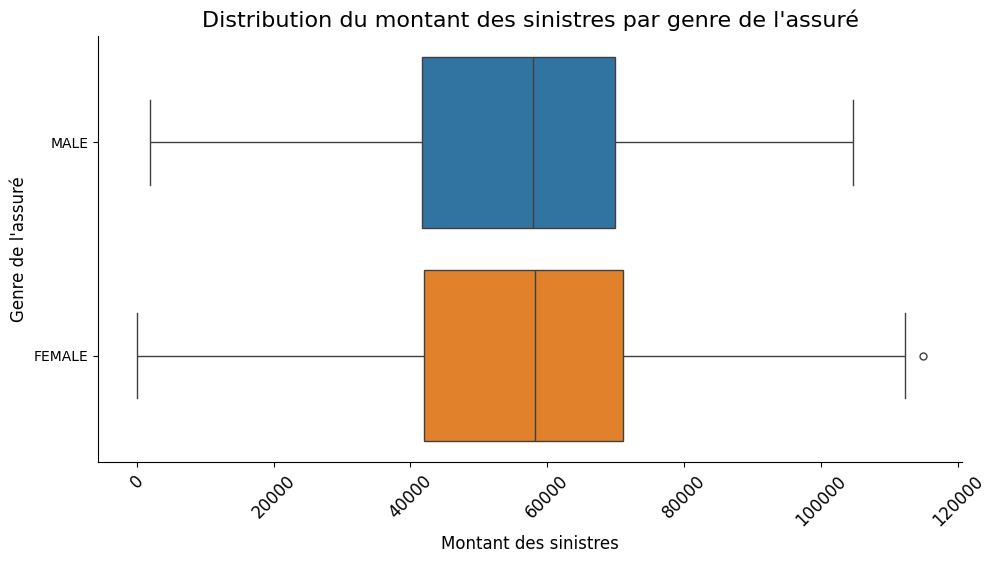

In [39]:
# Distribution du salaire par genre de l'assuré
sns.catplot(
    data=data,x="total_claim_amount", 
    y="insured_sex", hue="insured_sex", 
    kind="box", height=5, aspect=2,
)
# Ajout du titre du graphique
plt.title("Distribution du montant des sinistres par genre de l'assuré", fontsize=16)

# Rotation des étiquettes de l'axe x
plt.xticks(rotation=45, fontsize=12)

# Etiquettage des axes
plt.xlabel("Montant des sinistres", fontsize=12)
plt.ylabel("Genre de l'assuré", fontsize=12);

In [40]:
# Réaffichage des 5 premières lignes du DataFrame 
data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


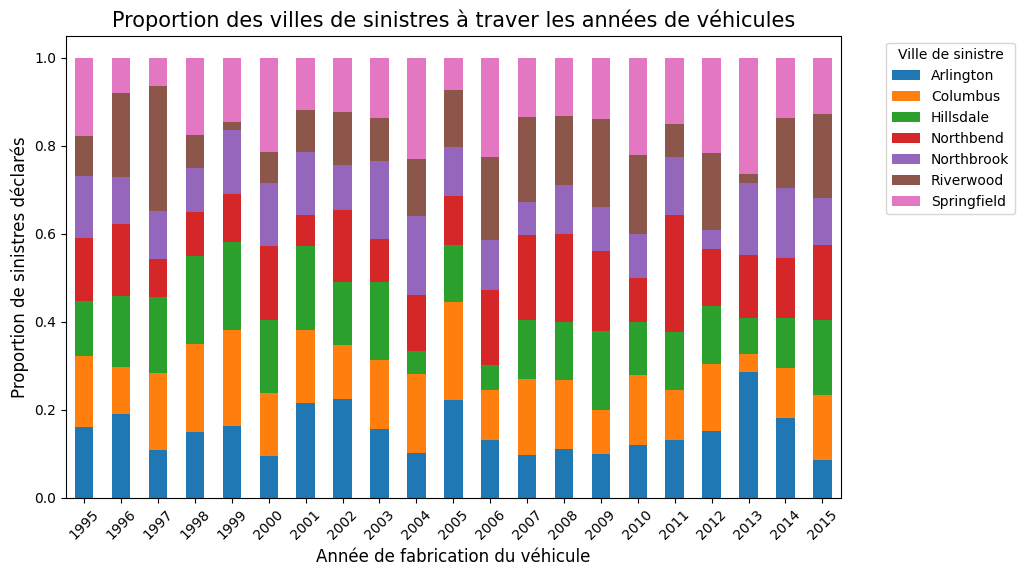

In [41]:
# Espace de travail
plt.figure(figsize=(10, 6))

pd.crosstab(data["auto_year"], data["incident_city"], normalize="index").plot(kind="bar", stacked = True, 
                                                                              rot = 45, ax=plt.gca())

# Titre du graphique
plt.title("Proportion des villes de sinistres à traver les années de véhicules", fontsize=15)

# Labélisation des axes
plt.xlabel("Année de fabrication du véhicule", fontsize=12)
plt.ylabel("Proportion de sinistres déclarés", fontsize=12)

# Légende du graphique
plt.legend(title="Ville de sinistre", bbox_to_anchor=(1.05, 1), loc="upper left");

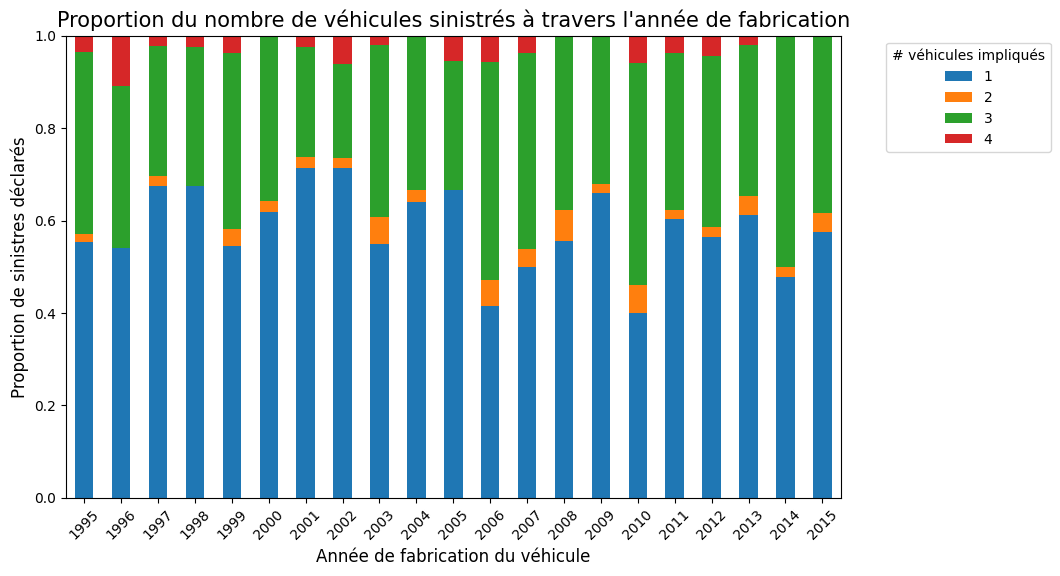

In [42]:
# Espace de travail
plt.figure(figsize=(10, 6))

# Proportion du nombre de véhicules sinistrés en fonction de l'année de fabrication des véhicules
pd.crosstab(data["auto_year"], data["number_of_vehicles_involved"], normalize="index").plot(kind="bar", stacked = True, 
                                                                              rot = 45, ax=plt.gca())

# Titre du graphique
plt.title("Proportion du nombre de véhicules sinistrés à travers l'année de fabrication", fontsize=15)

# Labélisation des axes
plt.xlabel("Année de fabrication du véhicule", fontsize=12)
plt.ylabel("Proportion de sinistres déclarés", fontsize=12)

# Légende du graphique
plt.legend(title="# véhicules impliqués", bbox_to_anchor=(1.05, 1), loc="upper left");

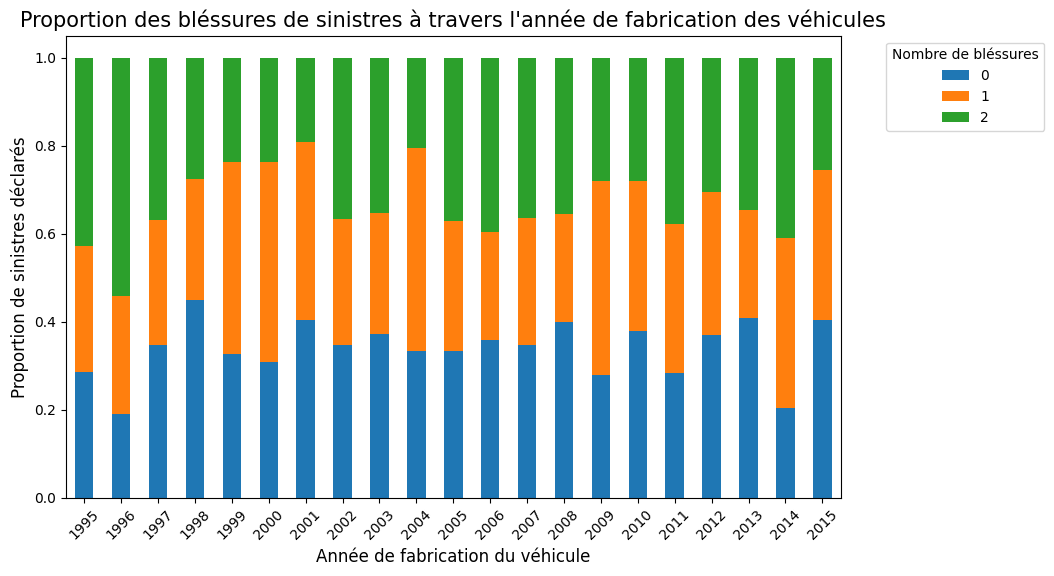

In [43]:
# Espace de travail
plt.figure(figsize=(10, 6))

# Proportion des bléssures de sinistres en fonction de l'année de fabrication des véhicules
pd.crosstab(data["auto_year"], data["bodily_injuries"], normalize="index").plot(kind="bar", stacked = True, 
                                                                              rot = 45, ax=plt.gca())
# Titre du graphique
plt.title("Proportion des bléssures de sinistres à travers l'année de fabrication des véhicules", fontsize=15)

# Labélisation des axes
plt.xlabel("Année de fabrication du véhicule", fontsize=12)
plt.ylabel("Proportion de sinistres déclarés", fontsize=12)

# Légende du graphique
plt.legend(title="Nombre de bléssures", bbox_to_anchor=(1.05, 1), loc="upper left");

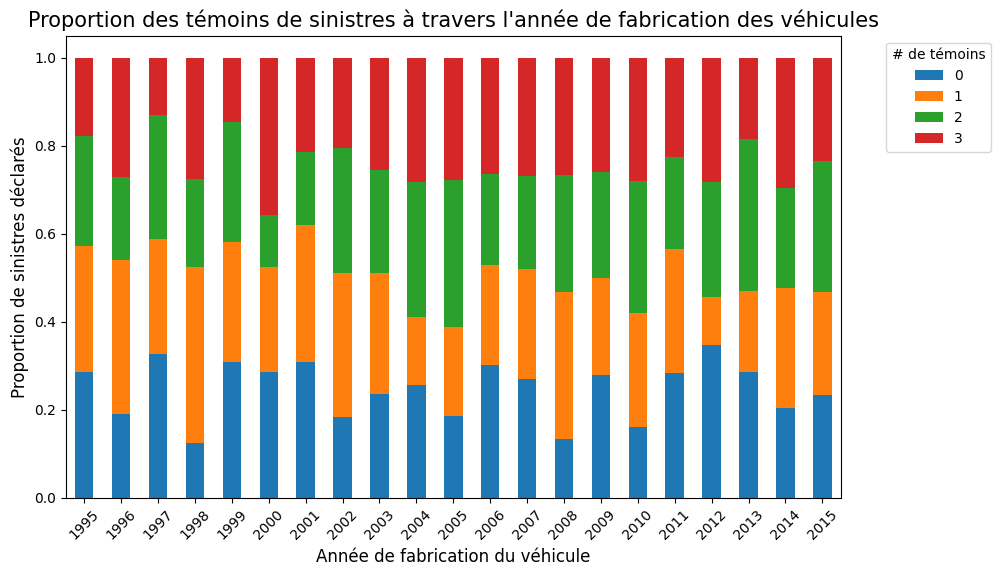

In [44]:
# Espace de travail
plt.figure(figsize=(10, 6))

# Proportion des bléssures de sinistres en fonction de l'année de fabrication des véhicules
pd.crosstab(data["auto_year"], data["witnesses"], normalize="index").plot(kind="bar", stacked = True, 
                                                                              rot = 45, ax=plt.gca())
# Titre du graphique
plt.title("Proportion des témoins de sinistres à travers l'année de fabrication des véhicules", fontsize=15)

# Labélisation des axes
plt.xlabel("Année de fabrication du véhicule", fontsize=12)
plt.ylabel("Proportion de sinistres déclarés", fontsize=12)

# Légende du graphique
plt.legend(title="# de témoins", bbox_to_anchor=(1.05, 1), loc="upper left");

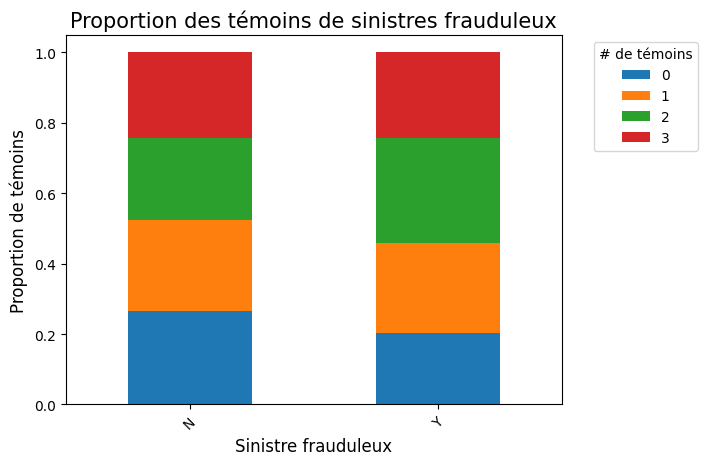

In [45]:
pd.crosstab(data["fraud_reported"], data["witnesses"], normalize="index").plot(kind="bar", stacked = True,
                                                                              rot = 45, ax=plt.gca())
# Titre du graphique
plt.title("Proportion des témoins de sinistres frauduleux", fontsize=15)

# Labélisation des axes
plt.xlabel("Sinistre frauduleux", fontsize=12)
plt.ylabel("Proportion de témoins", fontsize=12)

# Légende du graphique
plt.legend(title="# de témoins", bbox_to_anchor=(1.05, 1), loc="upper left");

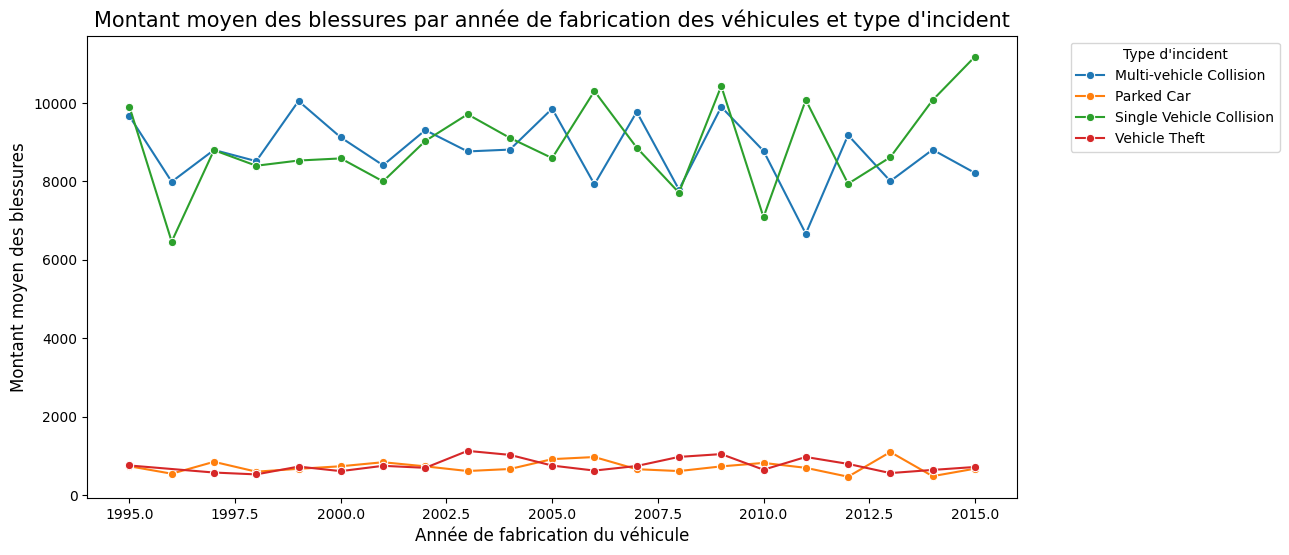

In [57]:
# DataFrame temporaire
temp_df = data.groupby(["auto_year", "incident_type"])["injury_claim"].mean().reset_index()

# Espace de travail
plt.figure(figsize=(12, 6))

# Visualisation de l'évolution du montant moyen des sinistres en fonction de l'année de fabrication des véhicules et du type d'incident
sns.lineplot(data=temp_df, x="auto_year", y="injury_claim", hue="incident_type", marker="o")

# Titre du graphique
plt.title("Montant moyen des blessures par année de fabrication des véhicules et type d'incident", fontsize=15)

# Labélisation des axes
plt.xlabel("Année de fabrication du véhicule", fontsize=12)
plt.ylabel("Montant moyen des blessures", fontsize=12)

# Légende du graphique
plt.legend(title="Type d'incident", bbox_to_anchor=(1.05, 1), loc="upper left");

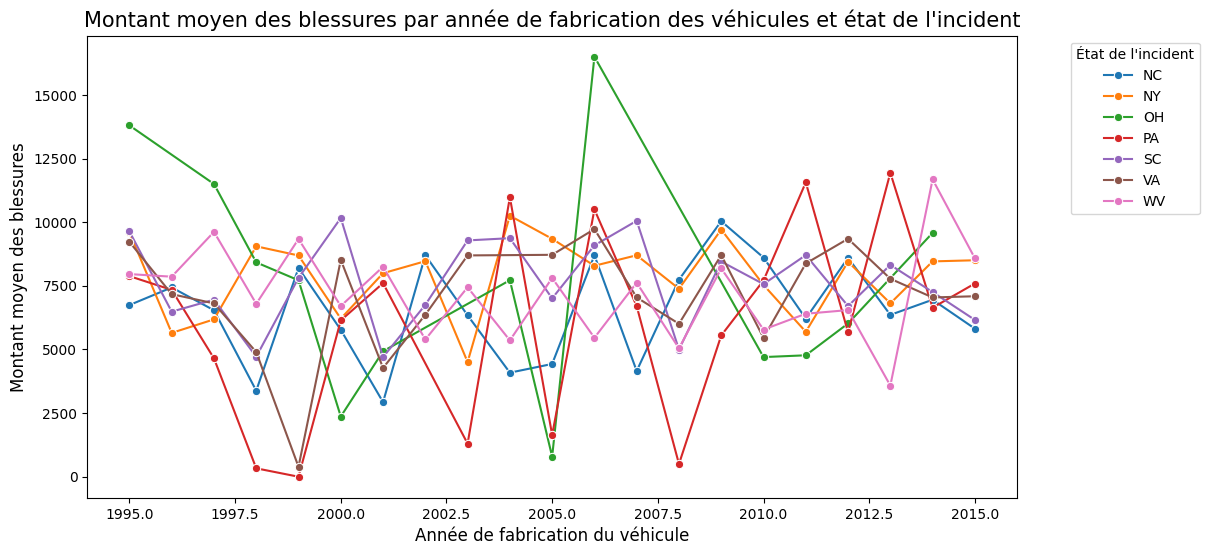

In [51]:
# DataFrame temporaire
temp_df = data.groupby(["auto_year", "incident_state"])["injury_claim"].mean().reset_index()

# Espace de travail
plt.figure(figsize=(12, 6))

# Visualisation de l'évolution du montant moyen des sinistres en fonction de l'année de fabrication des véhicules et du type d'incident
sns.lineplot(data=temp_df, x="auto_year", y="injury_claim", hue="incident_state", marker="o")

# Titre du graphique
plt.title("Montant moyen des blessures par année de fabrication des véhicules et état de l'incident", fontsize=15)

# Labélisation des axes
plt.xlabel("Année de fabrication du véhicule", fontsize=12)
plt.ylabel("Montant moyen des blessures", fontsize=12)

# Légende du graphique
plt.legend(title="État de l'incident", bbox_to_anchor=(1.05, 1), loc="upper left");

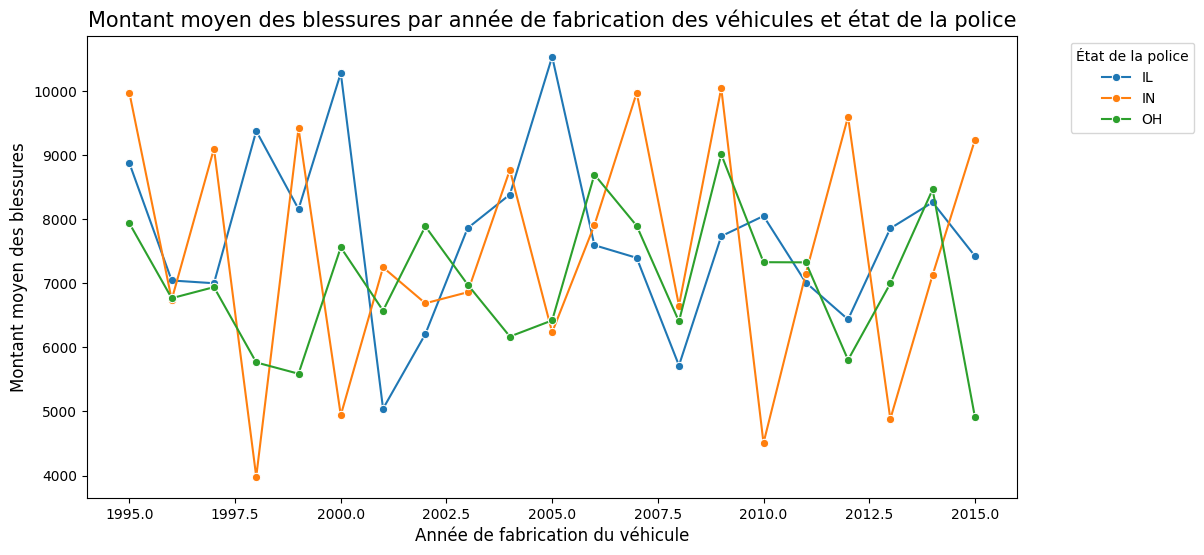

In [54]:
# DataFrame temporaire
temp_df = data.groupby(["auto_year", "policy_state"])["injury_claim"].mean().reset_index()

# Espace de travail
plt.figure(figsize=(12, 6))

# Visualisation de l'évolution du montant moyen des sinistres en fonction de l'année de fabrication des véhicules et du type d'incident
sns.lineplot(data=temp_df, x="auto_year", y="injury_claim", hue="policy_state", marker="o")

# Titre du graphique
plt.title("Montant moyen des blessures par année de fabrication des véhicules et état de la police", fontsize=15)

# Labélisation des axes
plt.xlabel("Année de fabrication du véhicule", fontsize=12)
plt.ylabel("Montant moyen des blessures", fontsize=12)

# Légende du graphique
plt.legend(title="État de la police", bbox_to_anchor=(1.05, 1), loc="upper left");

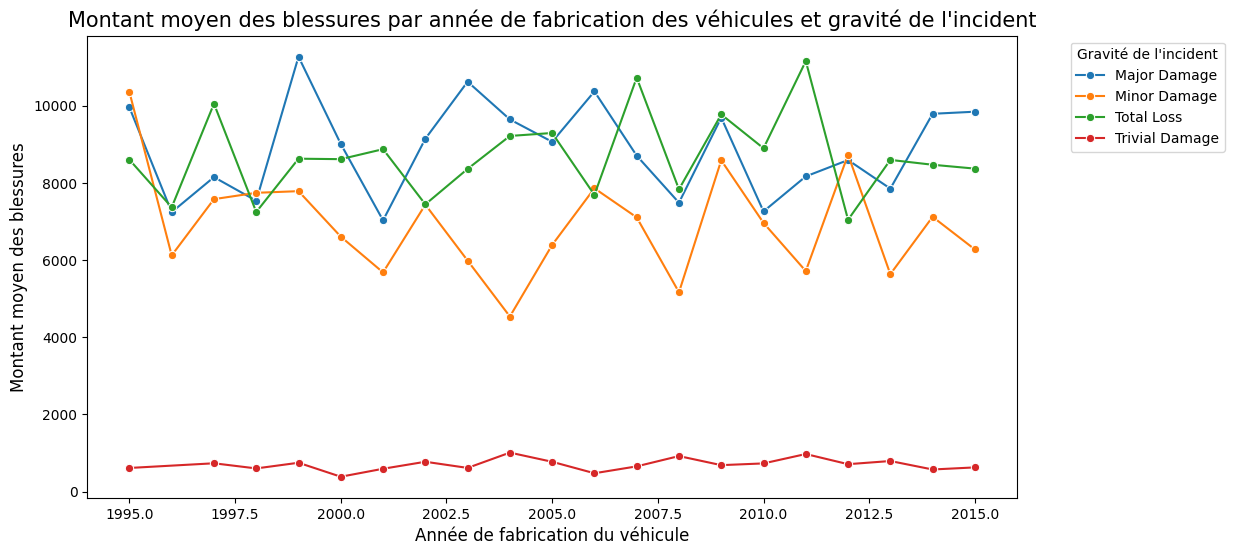

In [55]:
# DataFrame temporaire
temp_df = data.groupby(["auto_year", "incident_severity"])["injury_claim"].mean().reset_index()

# Espace de travail
plt.figure(figsize=(12, 6))

# Visualisation de l'évolution du montant moyen des sinistres en fonction de l'année de fabrication des véhicules et du type d'incident
sns.lineplot(data=temp_df, x="auto_year", y="injury_claim", hue="incident_severity", marker="o")

# Titre du graphique
plt.title("Montant moyen des blessures par année de fabrication des véhicules et gravité de l'incident", fontsize=15)

# Labélisation des axes
plt.xlabel("Année de fabrication du véhicule", fontsize=12)
plt.ylabel("Montant moyen des blessures", fontsize=12)

# Légende du graphique
plt.legend(title="Gravité de l'incident", bbox_to_anchor=(1.05, 1), loc="upper left");

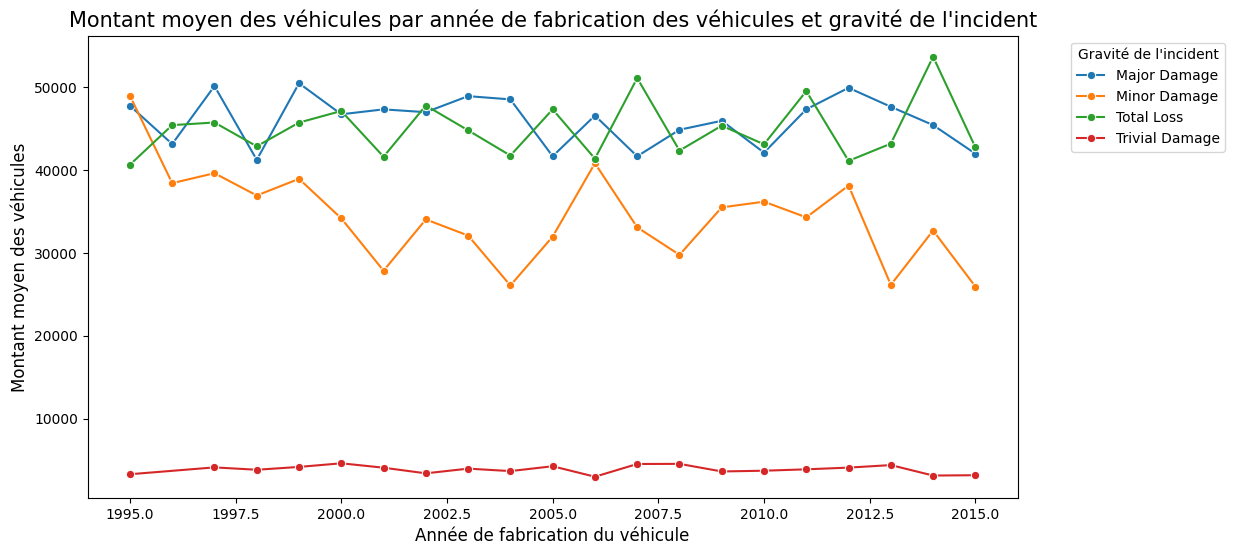

In [60]:
# DataFrame temporaire
temp_df = data.groupby(["auto_year", "incident_severity"])["vehicle_claim"].mean().reset_index()

# Espace de travail
plt.figure(figsize=(12, 6))

# Visualisation de l'évolution du montant moyen des véhicules en fonction de l'année de fabrication et de la gravité de l'incident
sns.lineplot(data=temp_df, x="auto_year", y="vehicle_claim", hue="incident_severity", marker="o")

# Titre du graphique
plt.title("Montant moyen des véhicules par année de fabrication des véhicules et gravité de l'incident", fontsize=15)

# Labélisation des axes
plt.xlabel("Année de fabrication du véhicule", fontsize=12)
plt.ylabel("Montant moyen des véhicules", fontsize=12)

# Légende du graphique
plt.legend(title="Gravité de l'incident", bbox_to_anchor=(1.05, 1), loc="upper left");

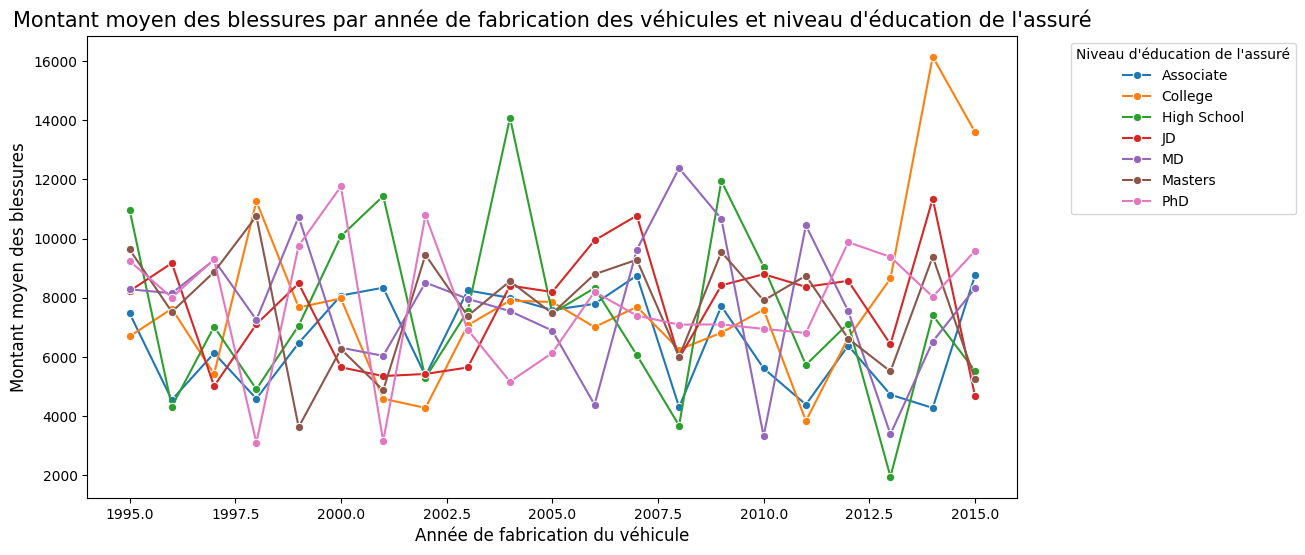

In [58]:
# DataFrame temporaire
temp_df = data.groupby(["auto_year", "insured_education_level"])["injury_claim"].mean().reset_index()

# Espace de travail
plt.figure(figsize=(12, 6))

# Visualisation de l'évolution du montant moyen des sinistres en fonction de l'année de fabrication des véhicules et du type d'incident
sns.lineplot(data=temp_df, x="auto_year", y="injury_claim", hue="insured_education_level", marker="o")

# Titre du graphique
plt.title("Montant moyen des blessures par année de fabrication des véhicules et niveau d'éducation de l'assuré", fontsize=15)

# Labélisation des axes
plt.xlabel("Année de fabrication du véhicule", fontsize=12)
plt.ylabel("Montant moyen des blessures", fontsize=12)

# Légende du graphique
plt.legend(title="Niveau d'éducation de l'assuré", bbox_to_anchor=(1.05, 1), loc="upper left");